<a href="https://colab.research.google.com/github/nakayamaerika411-lgtm/spotify-song-analysis/blob/main/Athma_ROC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
# We found the file name in the previous step.
file_path = "asthma_disease_data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rabieelkharoua/asthma-disease-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_779/726438050.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'asthma-disease-dataset' dataset.
First 5 records:    PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0       5034   63       0          1               0  15.848744        0   
1       5035   26       1          2               2  22.757042        0   
2       5036   57       0          2               1  18.395396        0   
3       5037   40       1          2               1  38.515278        0   
4       5038   61       0          0               3  19.283802        0   

   PhysicalActivity  DietQuality  SleepQuality  ...  LungFunctionFEV1  \
0          0.894448     5.488696      8.701003  ...          1.369051   
1          5.897329     6.341014      5.153966  ...          2.197767   
2          6.739367     9.196237      6.840647  ...          1.698011   
3          1.404503     5.826532      4.253036  ...          3.032037   
4          4.604493     3.127048      9.625799  ...          3.470589   

   LungFun

In [ ]:
import os
import kagglehub # kagglehubをインポート

# ダウンロードされたディレクトリ内のファイルを表示

# データセットのハンドルを定義
dataset_handle = "rabieelkharoua/asthma-disease-dataset"

# kagglehub.dataset_download() を使用してデータセットをダウンロードし、そのパスを取得
# この関数はダウンロードされたディレクトリのパスを返します。
df_path = kagglehub.dataset_download(dataset_handle)

# ダウンロードされたディレクトリ内のファイルを表示
print(os.listdir(df_path))

Using Colab cache for faster access to the 'asthma-disease-dataset' dataset.
['asthma_disease_data.csv']


In [ ]:
# 全ての列名を表示して、アレルギーに関連しそうな名前を探します
print(df.columns.tolist())

['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'PollutionExposure', 'PollenExposure', 'DustExposure', 'PetAllergy', 'FamilyHistoryAsthma', 'HistoryOfAllergies', 'Eczema', 'HayFever', 'GastroesophagealReflux', 'LungFunctionFEV1', 'LungFunctionFVC', 'Wheezing', 'ShortnessOfBreath', 'ChestTightness', 'Coughing', 'NighttimeSymptoms', 'ExerciseInduced', 'Diagnosis', 'DoctorInCharge']


In [ ]:
# 注目する変数を指定（'HayFever' か 'HistoryOfAllergies'）
target_factor = 'HayFever'

# 分割表の作成
cross_tab = pd.crosstab(df[target_factor], df['Diagnosis'])

# 結果の表示
print(f"--- {target_factor} vs Diagnosis ---")
print(cross_tab)

--- HayFever vs Diagnosis ---
Diagnosis     0   1
HayFever           
0          1689  97
1           579  27


In [ ]:
import statsmodels.api as sm

# 1. 目的変数(y)と説明変数(X)の選択
# リスク因子として考えられるものをリストアップします
features = ['Age', 'BMI', 'Smoking', 'PhysicalActivity', 'HayFever', 'HistoryOfAllergies']
X = df[features]
y = df['Diagnosis']

# 2. 定数項（切片）の追加
X = sm.add_constant(X)

# 3. ロジスティック回帰モデルの構築
model = sm.Logit(y, X).fit()

# 4. 結果の表示（ここに統計学のアピールが詰まっています）
print(model.summary())

# 5. 調整済みオッズ比と95%信頼区間の算出
params = model.params
conf = model.conf_int()
conf['Adjusted OR'] = np.exp(params)
conf.columns = ['Lower CI', 'Upper CI', 'Adjusted OR']
print(np.exp(conf))

Optimization terminated successfully.
         Current function value: 0.203298
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              Diagnosis   No. Observations:                 2392
Model:                          Logit   Df Residuals:                     2385
Method:                           MLE   Df Model:                            6
Date:                Sat, 02 May 2026   Pseudo R-squ.:                0.002935
Time:                        08:06:27   Log-Likelihood:                -486.29
converged:                       True   LL-Null:                       -487.72
Covariance Type:            nonrobust   LLR p-value:                    0.8259
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -2.5140      0.439     -5.725      0.000      -3.375      -1.653
Age  

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIFを計算する関数の定義
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    return vif_data

# 先ほどのモデルで使用した変数（定数項を含む）で実行
vif_results = calculate_vif(X)
print(vif_results)

              feature        VIF
0               const  23.248949
1                 Age   1.002722
2                 BMI   1.000658
3             Smoking   1.000315
4    PhysicalActivity   1.002859
5            HayFever   1.002249
6  HistoryOfAllergies   1.003801


In [ ]:
import statsmodels.formula.api as smf

# 交互作用項 (Smoking:HayFever) を含めたモデル
# 'Smoking * HayFever' と書くと、主効果と交互作用の両方が自動で含まれます
model_int = smf.logit('Diagnosis ~ Age + BMI + PhysicalActivity + Smoking * HayFever', data=df).fit()

print(model_int.summary())

Optimization terminated successfully.
         Current function value: 0.202930
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              Diagnosis   No. Observations:                 2392
Model:                          Logit   Df Residuals:                     2385
Method:                           MLE   Df Model:                            6
Date:                Sat, 02 May 2026   Pseudo R-squ.:                0.004736
Time:                        08:15:36   Log-Likelihood:                -485.41
converged:                       True   LL-Null:                       -487.72
Covariance Type:            nonrobust   LLR p-value:                    0.5934
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -2.5011      0.434     -5.767      0.000      -3.351      -1.651
Age        

In [ ]:
# 4つの組み合わせのダミーデータを作成して予測確率を算出
test_data = pd.DataFrame({
    'Age': df['Age'].mean(),
    'BMI': df['BMI'].mean(),
    'PhysicalActivity': df['PhysicalActivity'].mean(),
    'Smoking': [0, 0, 1, 1],
    'HayFever': [0, 1, 0, 1]
})

# 予測確率の算出
test_data['Prob'] = model_int.predict(sm.add_constant(test_data, has_constant='add'))

# Power BIに渡す用のテーブル
interaction_df = test_data[['Smoking', 'HayFever', 'Prob']]
print(interaction_df)

   Smoking  HayFever      Prob
0        0         0  0.057282
1        0         1  0.042020
2        1         0  0.035267
3        1         1  0.058422


In [ ]:
# ラベルを付与して分かりやすくする
plot_data = interaction_df.copy()
plot_data['Smoking_Label'] = plot_data['Smoking'].map({0: 'Non-Smoker', 1: 'Smoker'})
plot_data['HayFever_Label'] = plot_data['HayFever'].map({0: 'No Hay Fever', 1: 'Hay Fever'})

# CSVとして保存
plot_data.to_csv('asthma_interaction_summary.csv', index=False)

AUC: 0.5545


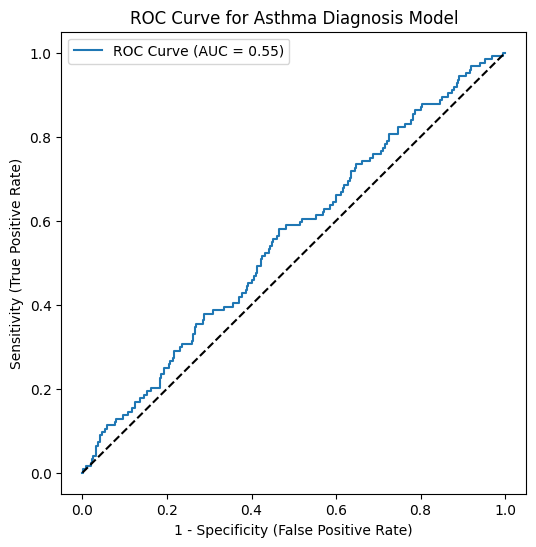

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. 予測確率の算出
y_probs = model_int.predict(sm.add_constant(X))

# 2. ROC曲線の要素（偽陽性率、真陽性率）を計算
fpr, tpr, thresholds = roc_curve(y, y_probs)
auc_value = roc_auc_score(y, y_probs)

# 3. AUCの表示
print(f"AUC: {auc_value:.4f}")

# 4. ROC曲線の描画（これをPower BIに載せる画像として保存できます）
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # 対角線
plt.xlabel('1 - Specificity (False Positive Rate)')
plt.ylabel('Sensitivity (True Positive Rate)')
plt.title('ROC Curve for Asthma Diagnosis Model')
plt.legend()
plt.show()

In [ ]:
# 'PollutionExposure' を加えた新しいモデル
# 交互作用もそのまま維持して、大気汚染の影響を調整します
formula_new = 'Diagnosis ~ Age + BMI + PhysicalActivity + Smoking * HayFever + PollutionExposure'
model_improved = smf.logit(formula_new, data=df).fit()

# AUCの再計算
y_probs_new = model_improved.predict(sm.add_constant(df[['Age', 'BMI', 'PhysicalActivity', 'Smoking', 'HayFever', 'PollutionExposure']]))
auc_new = roc_auc_score(df['Diagnosis'], y_probs_new)

print(f"Improved AUC: {auc_new:.4f}")
print(model_improved.summary())

Optimization terminated successfully.
         Current function value: 0.202915
         Iterations 7
Improved AUC: 0.5564
                           Logit Regression Results                           
Dep. Variable:              Diagnosis   No. Observations:                 2392
Model:                          Logit   Df Residuals:                     2384
Method:                           MLE   Df Model:                            7
Date:                Sat, 02 May 2026   Pseudo R-squ.:                0.004812
Time:                        08:55:41   Log-Likelihood:                -485.37
converged:                       True   LL-Null:                       -487.72
Covariance Type:            nonrobust   LLR p-value:                    0.6973
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -2.4515      0.470     -5.212      0.000      -3.373